In [128]:
from pathlib import Path
import datetime
import pandas as pd

In [129]:
from dagger_harmonics.data_utils import load_data, DEFAULT_DATA_PATH
data = load_data(DEFAULT_DATA_PATH)

In [130]:
data_idx = 0

In [131]:
print(len(data))  # 51060 observations
keys = data[data_idx].keys()
print(keys)
for key in keys:
    print(f"{key}: {type(data[data_idx][key])}")
    print(f"{key}: {len(data[data_idx][key])}")

51060
dict_keys(['past_omni', 'past_supermag', 'future_supermag', 'past_dates', 'future_dates', 'coords_radians'])
past_omni: <class 'numpy.ndarray'>
past_omni: 120
past_supermag: <class 'numpy.ndarray'>
past_supermag: 1
future_supermag: <class 'numpy.ndarray'>
future_supermag: 1
past_dates: <class 'numpy.ndarray'>
past_dates: 120
future_dates: <class 'numpy.ndarray'>
future_dates: 1
coords_radians: <class 'tuple'>
coords_radians: 2


In [132]:
print("--- Coords ---")
# Coords structured like (array[0][0], array[0][0]), where coords are (MLT, Colat)
coords = data[data_idx]["coords_radians"] # tuple of coordinates for the set of observations
print(len(coords))
mlt_coords = coords[0][0]  # radians
colat_coords = coords[1][0]  # radians
print(len(mlt_coords))  # 175
print(mlt_coords[:5])  # first 5 MLT coords in radians
print(len(colat_coords))  # 175
print(colat_coords[:5])  # first 5 colatitude coords in radians
# 175 stations in coords

--- Coords ---
2
175
[-3.04734487 -3.02116494 -2.83790536 -2.95309709 -2.83528737]
175
[0.42341688 0.40386919 0.7967428  0.73809974 0.65851273]


In [133]:
import matplotlib.pyplot as plt
import numpy as np

def polar_plot(lat, lon, values=None):
    fig, ax = plt.subplots(subplot_kw={'projection': 'polar'})
    ax.set_theta_zero_location('S')
    ax.set_theta_direction(-1)

    mlt_ticks = np.arange(0, 24, 3)                          # [0, 3, 6, ..., 21]
    theta_ticks = mlt_ticks / 24 * 2 * np.pi                 # convert MLT to radians
    ax.set_xticks(theta_ticks)
    ax.set_xticklabels([f"{int(m):02d}" for m in mlt_ticks])
    ax.set_xlabel("MLT (hours)")

    sc = ax.scatter(lat * 180 / np.pi, lon, c=values, cmap='viridis')
    if values is not None:
        plt.colorbar(sc, label='Value')
    
    return fig, ax

C:\Users\bugsp\AppData\Local\Temp\ipykernel_8292\2746021418.py:15: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  sc = ax.scatter(lat * 180 / np.pi, lon, c=values, cmap='viridis')


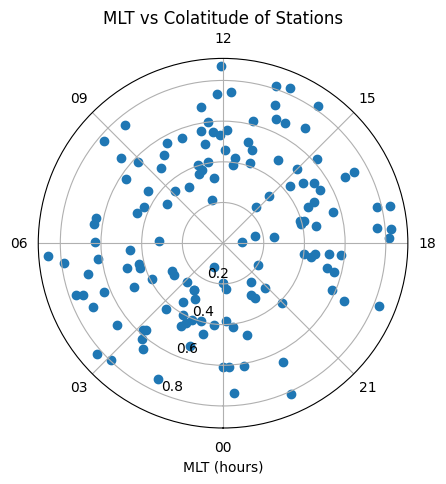

In [134]:
fig, ax = polar_plot(mlt_coords, colat_coords)
ax.set_title("MLT vs Colatitude of Stations")
plt.show()

In [135]:
print("--- Past SuperMAG ---")
past_supermag = data[data_idx]["past_supermag"][0]
print(len(past_supermag))
print(past_supermag[0]) #  [MAGLAT, MLT, dbe, dbn, ddbe_dt (derivative of dbe), ddbn_dt (derivative of dbn)]

--- Past SuperMAG ---
175
[65.74 15.23  1.1  -4.   -1.   -0.2 ]


In [136]:
past_supermag_df = pd.DataFrame(past_supermag, columns=["MAGLAT", "MLT", "dbe", "dbn", "ddbe_dt", "ddbn_dt"])
past_supermag_df['MAGLAT'] = np.deg2rad(90 - past_supermag_df["MAGLAT"]) # lat
past_supermag_df['MLT'] = (past_supermag_df["MLT"] / 24)* 2 * np.pi # lon
print(past_supermag_df.head())

     MAGLAT       MLT  dbe  dbn  ddbe_dt  ddbn_dt
0  0.423417  3.987205  1.1 -4.0     -1.0     -0.2
1  0.403869  3.961025  3.8 -5.9     -0.1     -0.4
2  0.796743  3.775147 -1.2 -6.4      0.0      0.0
3  0.738100  3.890339 -0.8 -4.8      0.0      0.0
4  0.658513  3.775147 -1.0 -5.9     -0.2      0.1


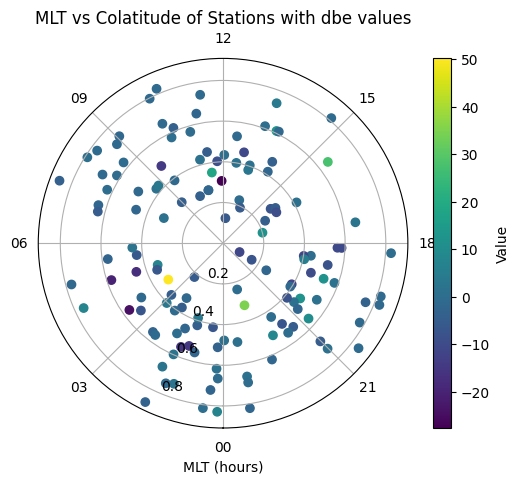

In [137]:
fig, ax = polar_plot(past_supermag_df["MLT"], past_supermag_df["MAGLAT"], past_supermag_df["dbe"])
ax.set_title("MLT vs Colatitude of Stations with dbe values")
plt.show()

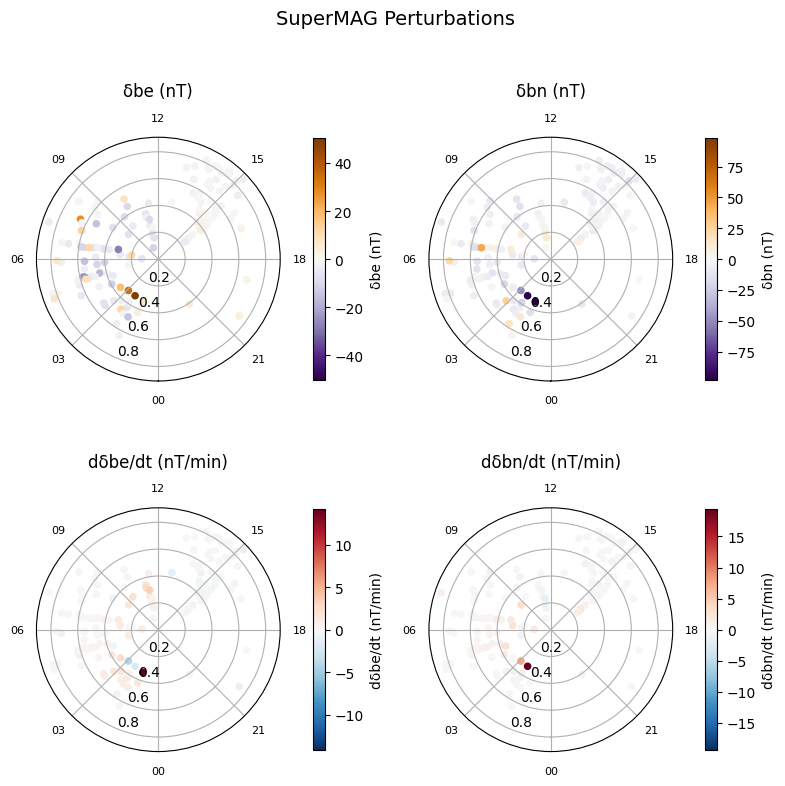

In [138]:
channels = [
    (past_supermag_df["dbe"],     "δbe (nT)",      "PuOr_r"),
    (past_supermag_df["dbn"],     "δbn (nT)",      "PuOr_r"),
    (past_supermag_df["ddbe_dt"], "dδbe/dt (nT/min)", "RdBu_r"),
    (past_supermag_df["ddbn_dt"], "dδbn/dt (nT/min)", "RdBu_r"),
]

fig, axes = plt.subplots(2, 2, subplot_kw={"projection": "polar"}, figsize=(8, 8))

mlt_rad = past_supermag_df["MLT"] # lon
mcolat_rad = past_supermag_df["MAGLAT"]  # lat

for ax, (values, label, cmap) in zip(axes.ravel(), channels):
    ax.set_theta_zero_location("S")
    ax.set_theta_direction(-1)
    mlt_ticks = np.arange(0, 24, 3)
    ax.set_xticks(mlt_ticks / 24 * 2 * np.pi)
    ax.set_xticklabels([f"{int(m):02d}" for m in mlt_ticks], fontsize=8)
    absmax = np.nanmax(np.abs(values))
    sc = ax.scatter(mlt_rad, mcolat_rad, c=values, cmap=cmap, vmin=-absmax, vmax=absmax, s=20)
    fig.colorbar(sc, ax=ax, shrink=0.7, pad=0.1, label=label)
    ax.set_title(label, pad=12)

fig.suptitle("SuperMAG Perturbations", fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

In [139]:
print("--- Future Dates ---")
future_dates = data[data_idx]["future_dates"][0]
print(len(future_dates))
print(future_dates[0])
formated_date = datetime.datetime.fromtimestamp(future_dates[0], tz=datetime.UTC)
print(formated_date)

--- Future Dates ---
1
1264520520.0
2010-01-26 15:42:00+00:00


In [140]:
print("-- Future SuperMAG ---")
future_supermag = data[data_idx]["future_supermag"][0]
print(len(future_supermag))
print(future_supermag[0])

-- Future SuperMAG ---
175
[65.74 17.64  1.4  -1.   -0.9  -1.2 ]


In [141]:
print("--- Past Dates ---")
past_date = data[data_idx]["past_dates"]
print(len(past_date))
print(past_date[0])
formated_past_date = datetime.datetime.fromtimestamp(past_date[0], tz=datetime.UTC)
print(formated_past_date)

--- Past Dates ---
120
1264511520.0
2010-01-26 13:12:00+00:00


In [142]:
print("-- Past OMNI ---")
past_omni = data[data_idx]["past_omni"]
print(len(past_omni))

-- Past OMNI ---
120


## Spherical Harmonic Transform via torch-harmonics

`torch-harmonics` requires data on a **regular grid**. Since stations are scattered, we first interpolate onto an equiangular grid, then apply `RealSHT`.

In [143]:
import torch
import torch_harmonics
from scipy.interpolate import griddata

# Grid resolution — increase for finer resolution (must be even for RealSHT)
NLAT, NLON = 64, 128

# Equiangular grid: colatitude [0, pi], longitude [0, 2pi)
lat_grid = np.linspace(0, np.pi, NLAT)
lon_grid = np.linspace(0, 2 * np.pi, NLON, endpoint=False)
lon_mesh, lat_mesh = np.meshgrid(lon_grid, lat_grid)  # (NLAT, NLON)

mlt_vals = mlt_rad.values
mcolat_vals = mcolat_rad.values
coord_finite = np.isfinite(mlt_vals) & np.isfinite(mcolat_vals)

def scatter_to_grid(values, method="linear"):
    """Interpolate scattered station values onto the regular (NLAT, NLON) grid."""
    mask = coord_finite & np.isfinite(values)
    points = np.column_stack([mlt_vals[mask], mcolat_vals[mask]])
    return griddata(
        points,
        values[mask],
        (lon_mesh, lat_mesh),
        method=method,
        fill_value=0.0,
    )

grid_dbe = scatter_to_grid(past_supermag_df["dbe"].values)
grid_dbn = scatter_to_grid(past_supermag_df["dbn"].values)

print(f"Grid shape: {grid_dbe.shape}  (NLAT={NLAT}, NLON={NLON})")
print(f"dbe grid range: [{grid_dbe.min():.2f}, {grid_dbe.max():.2f}] nT")

Grid shape: (64, 128)  (NLAT=64, NLON=128)
dbe grid range: [-25.06, 42.83] nT


Coefficient tensor shape: (1, 1, 64, 65)  (lmax=64)


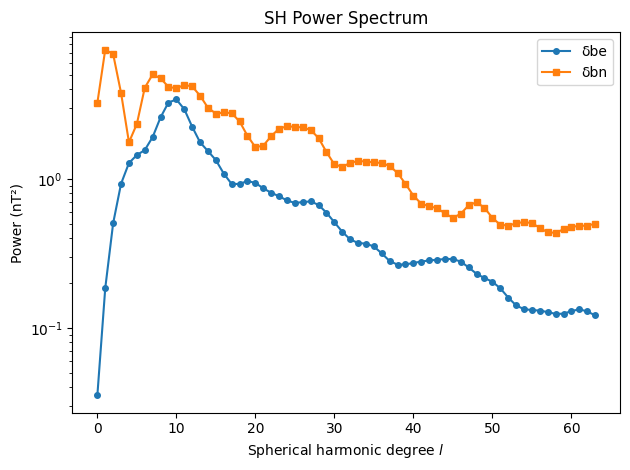

In [144]:
# Apply RealSHT — input shape: (batch, channels, NLAT, NLON)
sht = torch_harmonics.RealSHT(NLAT, NLON, grid="equiangular")
isht = torch_harmonics.InverseRealSHT(NLAT, NLON, grid="equiangular")

def to_sht(grid_np):
    t = torch.from_numpy(grid_np).float().unsqueeze(0).unsqueeze(0)  # (1,1,NLAT,NLON)
    return sht(t)  # (1,1,lmax,mmax+1) complex — keep batched

coeffs_dbe = to_sht(grid_dbe)
coeffs_dbn = to_sht(grid_dbn)

lmax = coeffs_dbe.shape[-2]
print(f"Coefficient tensor shape: {tuple(coeffs_dbe.shape)}  (lmax={lmax})")

# Power per degree l: sum |C_lm|^2 over m
def power_spectrum(coeffs):
    c = coeffs.squeeze()  # (lmax, mmax+1)
    power = []
    for l in range(c.shape[0]):
        p = c[l, 0].abs().pow(2)
        if c.shape[1] > 1:
            p = p + 2 * c[l, 1:l+1].abs().pow(2).sum()
        power.append(p.item())
    return np.array(power)

ps_dbe = power_spectrum(coeffs_dbe)
ps_dbn = power_spectrum(coeffs_dbn)

fig, ax = plt.subplots()
degrees = np.arange(lmax)
ax.semilogy(degrees, ps_dbe, label="δbe", marker="o", ms=4)
ax.semilogy(degrees, ps_dbn, label="δbn", marker="s", ms=4)
ax.set_xlabel("Spherical harmonic degree $l$")
ax.set_ylabel("Power (nT²)")
ax.set_title("SH Power Spectrum")
ax.legend()
plt.tight_layout()
plt.show()

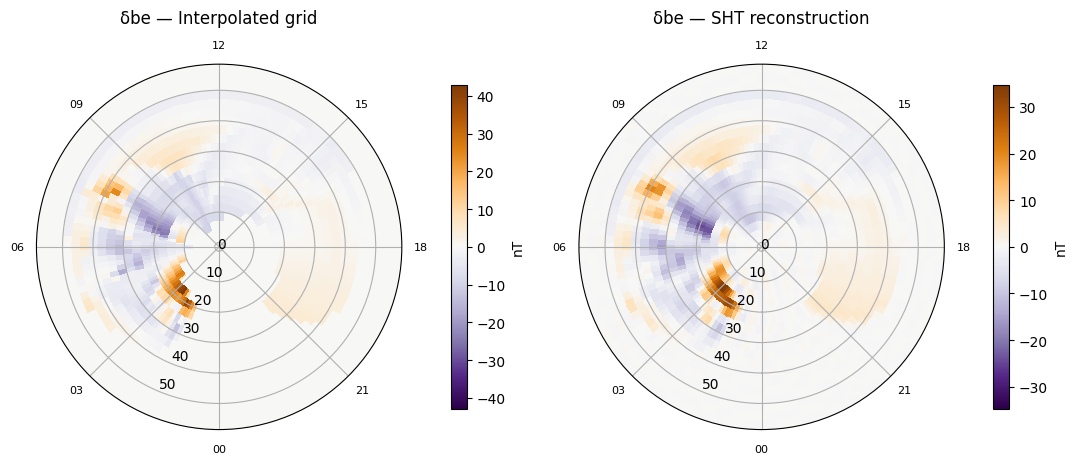

In [145]:
# Reconstruct from SH coefficients — shown in polar coordinates
def reconstruct(grid_np):
    t = torch.from_numpy(grid_np).float().unsqueeze(0).unsqueeze(0)
    return isht(sht(t)).squeeze().numpy()

recon_dbe = reconstruct(grid_dbe)

# Clip to polar cap to match the scatter plots above
CAP_RAD = np.deg2rad(60)
cap = lat_grid <= CAP_RAD
theta_mesh, r_mesh = np.meshgrid(lon_grid, lat_grid[cap])

fig, axes = plt.subplots(1, 2, subplot_kw={"projection": "polar"}, figsize=(11, 5))

for ax, data, title in zip(axes, [grid_dbe, recon_dbe], ["Interpolated grid", "SHT reconstruction"]):
    ax.set_theta_zero_location("S")
    ax.set_theta_direction(-1)
    mlt_ticks = np.arange(0, 24, 3)
    ax.set_xticks(mlt_ticks / 24 * 2 * np.pi)
    ax.set_xticklabels([f"{int(m):02d}" for m in mlt_ticks], fontsize=8)

    absmax = np.abs(data).max()
    im = ax.pcolormesh(
        theta_mesh, np.rad2deg(r_mesh), data[cap, :],
        cmap="PuOr_r", vmin=-absmax, vmax=absmax, shading="auto"
    )
    ax.set_title(f"δbe — {title}", pad=12)
    fig.colorbar(im, ax=ax, shrink=0.7, pad=0.1, label="nT")

plt.tight_layout()
plt.show()

In [146]:
# dbH = sqrt(dbe^2 + dbn^2) — horizontal perturbation magnitude (always positive)
dbH_vals = np.sqrt(past_supermag_df["dbe"].values**2 + past_supermag_df["dbn"].values**2)

grid_dbH = scatter_to_grid(dbH_vals)
coeffs_dbH = to_sht(grid_dbH)
recon_dbH = reconstruct(grid_dbH)

ps_dbH = power_spectrum(coeffs_dbH)
print(f"dbH range at stations: [{dbH_vals.min():.1f}, {dbH_vals.max():.1f}] nT")
print(f"dbH grid range:        [{grid_dbH.min():.1f}, {grid_dbH.max():.1f}] nT")

dbH range at stations: [nan, nan] nT
dbH grid range:        [0.0, 97.8] nT


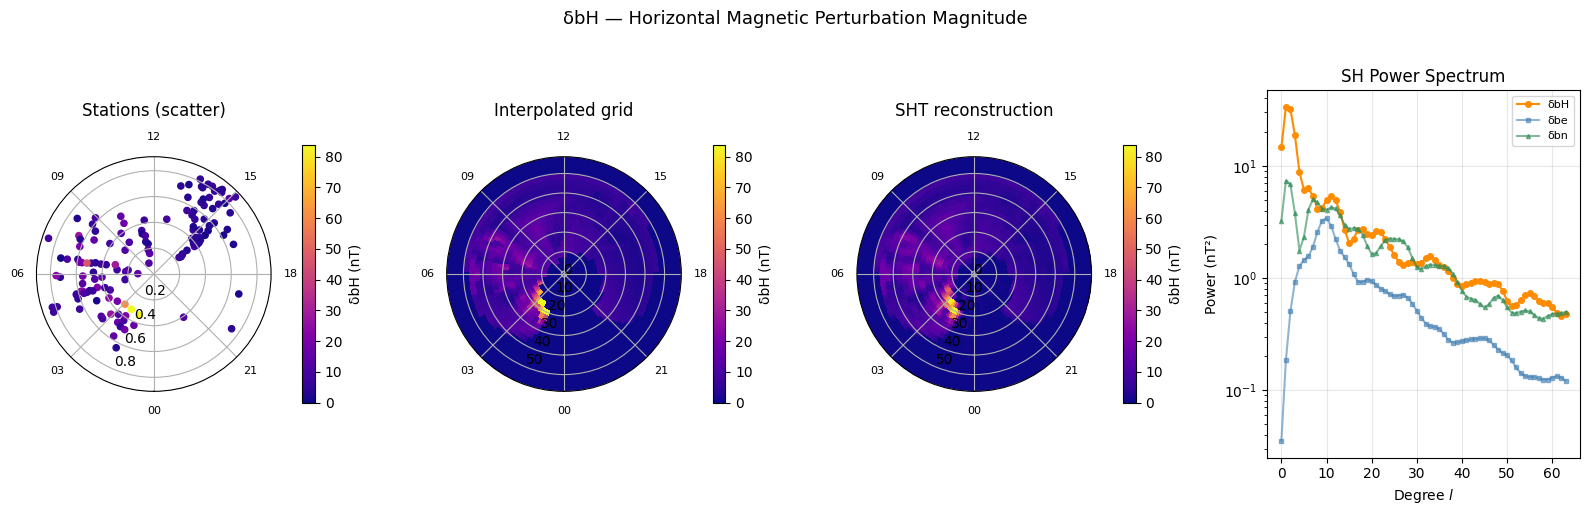

In [147]:
fig = plt.figure(figsize=(16, 5))

polar_specs = [
    {"label": "Stations (scatter)",   "data": None,       "scatter": True},
    {"label": "Interpolated grid",    "data": grid_dbH,   "scatter": False},
    {"label": "SHT reconstruction",  "data": recon_dbH,  "scatter": False},
]

vmax_dbH = np.nanpercentile(dbH_vals, 99)

def style_ax(ax):
    ax.set_theta_zero_location("S")
    ax.set_theta_direction(-1)
    mlt_ticks = np.arange(0, 24, 3)
    ax.set_xticks(mlt_ticks / 24 * 2 * np.pi)
    ax.set_xticklabels([f"{int(m):02d}" for m in mlt_ticks], fontsize=8)

for i, spec in enumerate(polar_specs):
    ax = fig.add_subplot(1, 4, i + 1, projection="polar")
    style_ax(ax)
    ax.set_title(spec["label"], pad=12)

    if spec["scatter"]:
        sc = ax.scatter(mlt_rad, mcolat_rad, c=dbH_vals, cmap="plasma",
                        vmin=0, vmax=vmax_dbH, s=20)
        fig.colorbar(sc, ax=ax, shrink=0.7, pad=0.1, label="δbH (nT)")
    else:
        im = ax.pcolormesh(theta_mesh, np.rad2deg(r_mesh), spec["data"][cap, :],
                           cmap="plasma", vmin=0, vmax=vmax_dbH, shading="auto")
        fig.colorbar(im, ax=ax, shrink=0.7, pad=0.1, label="δbH (nT)")

# Power spectrum panel
ax_ps = fig.add_subplot(1, 4, 4)
ax_ps.semilogy(np.arange(len(ps_dbH)), ps_dbH, marker="o", ms=4, color="darkorange", label="δbH")
ax_ps.semilogy(np.arange(len(ps_dbe)), ps_dbe, marker="s", ms=3, color="steelblue", alpha=0.6, label="δbe")
ax_ps.semilogy(np.arange(len(ps_dbn)), ps_dbn, marker="^", ms=3, color="seagreen", alpha=0.6, label="δbn")
ax_ps.set_xlabel("Degree $l$")
ax_ps.set_ylabel("Power (nT²)")
ax_ps.set_title("SH Power Spectrum")
ax_ps.legend(fontsize=8)
ax_ps.grid(True, alpha=0.3)

fig.suptitle("δbH — Horizontal Magnetic Perturbation Magnitude", fontsize=13, y=1.02)
plt.tight_layout()
plt.show()